In [ ]:
import pandas as pd, stats_lib as sl, plot_lib as pl

In [ ]:
dr_df = pd.read_csv("input/driving_clustering_data.txt", sep=r"\s+")
dr_df

In [ ]:
sp = pl.ScatterPlot(dr_df['distance_feature'], dr_df['speeding_feature'])
pl.SubPlot([[sp]]).plot()

In [ ]:
dr_df['normalized_distance_feature'] = sl.normalize_list(dr_df['distance_feature'])
dr_df['normalized_speeding_feature'] = sl.normalize_list(dr_df['speeding_feature'])

In [ ]:
sp = pl.ScatterPlot(dr_df['normalized_distance_feature'], dr_df['normalized_speeding_feature'])
pl.SubPlot([[sp]]).plot()

In [ ]:
starting_centroid_x_vals = [-0.5, 2]
starting_centroid_y_vals = [1, 1]
distances_to_centroids = sl.get_distances_for_multiple_points(dr_df['normalized_distance_feature'], dr_df['normalized_speeding_feature'], starting_centroid_x_vals, starting_centroid_y_vals)
dr_df['distances_to_centroids'] = distances_to_centroids

In [ ]:
dr_df['centroid_idx'] = dr_df['distances_to_centroids'].apply(lambda x: x.index(min(x)))

/Users/247304/Projects/clustering/plot_lib.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


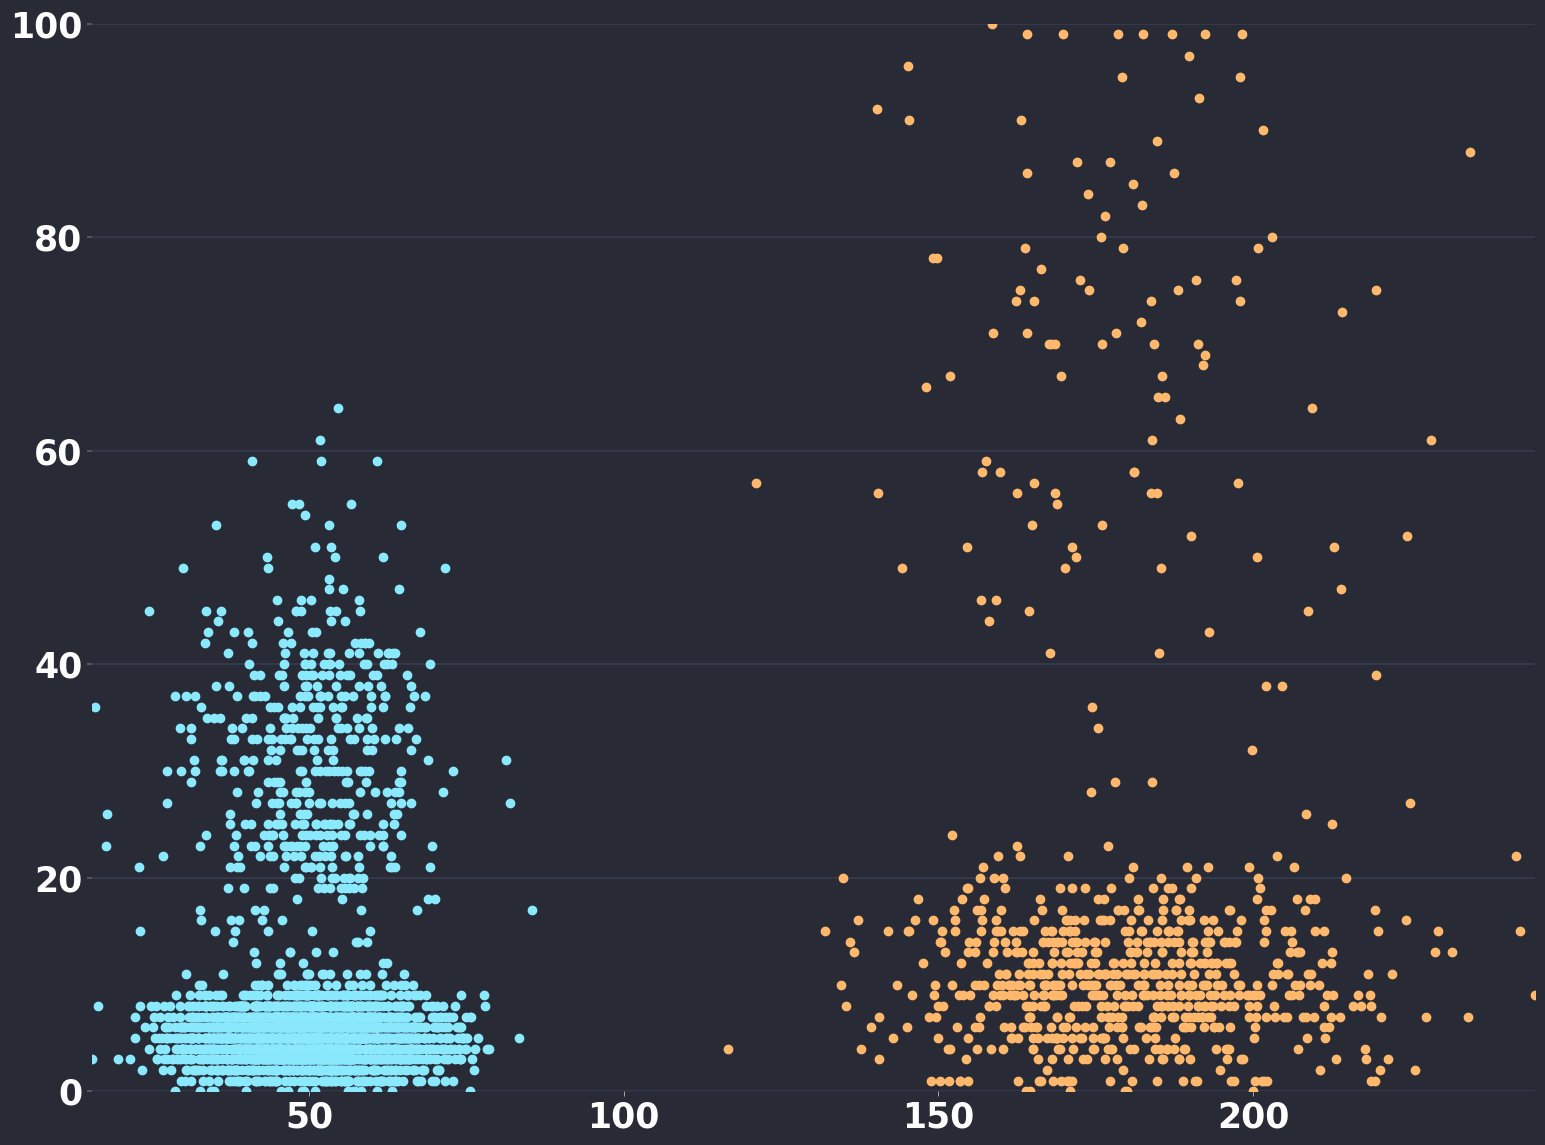

In [15]:
plots = []
for idx in dr_df['centroid_idx'].unique():
    rows = dr_df.query(f'centroid_idx=={idx}')
    x_vals = rows['distance_feature']
    y_vals = rows['speeding_feature']
    sp = pl.ScatterPlot(x_vals, y_vals)
    plots.append(sp)
pl.SubPlot([plots]).plot()
# dr_df